## Домашнее задание 2. Классификация тональности

В этом задании мы будем решать задачу классификации тональности отзывов о ресторанах. Задачу классификации тональности текста часто решают для автоматизации анализа обратной связи в случаях, когда пользователи не ставят числовую оценку. Например, так можно проанализировать общее настроение комментариев под постом в социальной сети или под видео на видеохостинговой платформе.

В этом задании вам предстоит:

1. Немного предобработать данные.
2. Обучить несколько моделей для задачи классификации и сравнить их между собой:
    1. Наивный Байес
    1. TF-IDF
    1. Сверточную модель

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

c:\Users\phoen\Desktop\DL_course\DL_NLP\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Начнем с загрузки данных. Мы будем использовать датасет Yelp. Он содержит около 450 тысяч коротких негативных и позитивных отзывов о ресторанах. Это академический датасет, и раньше он часто использовался для тестирования моделей в научных работах.

In [2]:
train_data = pd.read_csv('yelp_train.csv')
test_data = pd.read_csv('yelp_test.csv')

texts_train = train_data.text
labels_train = train_data.label
texts_test = test_data.text
labels_test = test_data.label

In [3]:
train_data.shape, test_data.shape

((443259, 2), (1000, 2))

In [4]:
texts_train[:5]

0    the service and food is always consistent and ...
1                                      honest people .
2                          it 's all very impressive .
3                              its decor is horrible .
4    definitely will go back to try some of their o...
Name: text, dtype: object

Посмотрим на распределение классов. Для оценки качества можем использовать обычную точность (accuracy), так как классы достаточно сбалансированы.

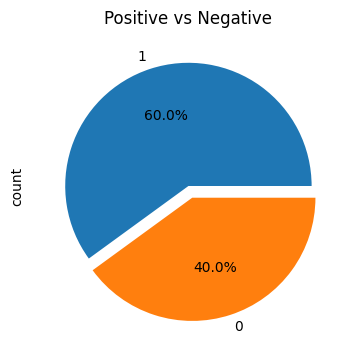

In [6]:
labels_train.value_counts().plot(kind='pie', explode=[0, 0.1], figsize=(4, 4), autopct='%1.1f%%')
plt.title("Positive vs Negative")
plt.show()

## Предобработка данных

Каждый датасет требует индивидуального подхода и предобработка данных зависит от задачи, которую мы решаем. Из стандартных практик для задачи классификации можно выделить _приведение к нижнему регистру_, _лемматизацию_ и _удаление пунктуации_. То есть все то, что почти не меняет содержащуюся информацию. Однако для каждой задачи __обязательно__ надо думать, какую информацию точно нельзя удалять. Например, для этой задачи не стоит удалять стоп-слова (not, no, isn't, always и т.д.), потому что они могут быть важны для классификации тональности. Если у вас нет интуиции о том, какая информация может быть полезна, то __лучше сохранить все__.

__Задание 1.__
Приведите тренировочные и тестовые данные к нижнему регистру, удалите пунктуацию и лемматизуйте. Для проверки запишите обработанный тренировочный корпус в текстовый файл `clean_text_train.txt` в формате обычного текста, в котором тексты отделены переносом строки и сдайте в грейдер.

In [9]:
for i in texts_train[:5]:
    print(i)

the service and food is always consistent and great !
honest people .
it 's all very impressive .
its decor is horrible .
definitely will go back to try some of their other options .


In [8]:
from nltk.stem import WordNetLemmatizer
from string import punctuation
import re 
def clean_texts(texts) -> list:
    clean_text = []
    lemmitizer = WordNetLemmatizer() # lem object
    pattern = f"[{punctuation}]"
    for words in texts:
        new_words = re.sub(pattern,"",words)
        new_words_2 = [lemmitizer.lemmatize(word.lower()) for word in new_words.split()]
        clean_text.append(new_words_2)
        
        



    return clean_text

clean_texts_train = clean_texts(texts_train)

with open('clean_text_train.txt', 'w') as f:
    for text in clean_texts_train:
        f.write(' '.join(text))
        f.write('\n')

In [9]:
clean_texts_test = clean_texts(texts_test)

In [32]:
! head clean_text_train.txt

"head" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


## Метрика

Как уже было сказано, для оценки качества будем считать точность. Загрузим эту метрику из `sklearn`.

In [10]:
from sklearn.metrics import accuracy_score

## Наивный Байес

Наивный байесовский классификатор считает все слова в тексте независимыми и предсказывает класс по формуле
$$
\hat{y} = \underset{y}{\text{argmax}} \, p(y) \prod_{i=1}^n p(x_i | y)
$$
или
$$
\hat{y} = \underset{y}{\text{argmax}} \, p(y) \prod_{w \in V} p(w | y)^{\text{count}(w)}
$$

__Задание 2.__ Обучите Наивный Байес на Bag of Words представлениях текстов. В качестве модели возьмите `MultinomialNB` из `sklearn`. Замерьте точность на тестовой выборке. Если вы все сделали правильно, у вас должно получиться не меньше 0.91.   
Оформите решение в виде функции `train_nb_model`. Она принимает на вход список текстов (список списков слов) и список их меток и возвращает обученную модель `MultinomialNB` вместе с BoW моделью `CountVectorizer`.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [39]:
bow_vectorizer = CountVectorizer( preprocessor=lambda x: " ".join(x))
bow_vectorizer.fit(clean_texts_train)

CountVectorizer(preprocessor=<function <lambda> at 0x0000028A25A8F5B0>)

In [42]:
t = bow_vectorizer.transform(clean_texts_train)

In [40]:
print(bow_vectorizer.vocabulary_)

{'the': 7298, 'service': 6422, 'and': 348, 'food': 2919, 'is': 3829, 'always': 314, 'consistent': 1667, 'great': 3219, 'honest': 3514, 'people': 5314, 'it': 3835, 'all': 280, 'very': 7809, 'impressive': 3676, 'decor': 1980, 'horrible': 3538, 'definitely': 2000, 'will': 8039, 'go': 3151, 'back': 614, 'to': 7405, 'try': 7561, 'some': 6712, 'of': 4998, 'their': 7303, 'other': 5103, 'option': 5073, 'had': 3303, 'grilled': 3241, 'artichoke': 483, 'which': 8008, 'wa': 7872, 'phenomenal': 5368, 'caesar': 1130, 'salad': 6229, 'burger': 1081, 'cooked': 1711, 'fresh': 2989, 'upon': 7718, 'order': 5080, 'shiloh': 6487, 'grill': 3239, 'ha': 3299, 'proved': 5684, 'disappointment': 2163, 'yet': 8159, 'again': 221, 'this': 7334, 'review': 6048, 'still': 6936, 'stand': 6876, 'true': 7551, 'item': 3838, 'were': 7987, 'bland': 845, 'we': 7950, 'add': 163, 'salt': 6239, 'good': 3169, 'probably': 5642, 'wo': 8072, 'nt': 4958, 'another': 372, 'hooter': 3527, 'for': 2926, 'year': 8144, 'or': 5075, 'so': 668

In [53]:
from typing import List
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

def train_nb_model(texts: List[List[str]], labels: List[int]) -> (MultinomialNB, CountVectorizer):
    bow_vectorizer = CountVectorizer( preprocessor=lambda x: " ".join(x))
    model = MultinomialNB()
    bowed_train_data = bow_vectorizer.fit_transform(texts)
    model.fit(bowed_train_data,labels)
    return model,bow_vectorizer

In [54]:
model, vect = train_nb_model(clean_texts_train, labels_train)

In [56]:
vect

CountVectorizer(preprocessor=<function train_nb_model.<locals>.<lambda> at 0x0000028A282623B0>)

## TF-IDF + Логистическая регрессия

Наивный Байес редко работает хорошо, так как он очень чувствителен к редким словам. Гораздо более распространенный и рабочий подход – любой классификатор (логистиченая регрессия, SVM, случайный лес, градиентный бустинг) поверх TF-IDF признаков.

__Задание 3.__ Закодируйте тексты с помощью TF-IDF и обучите на этом логистическую регрессию. Помните, что считать TF-IDF нужно только на обучающей выборке. Удалось ли таким подходом обогнать Наивный Байес?   
В грейдер сдайте код для функции `train_lr_model`. Структура функции аналогична с функции из предыдущего задания. Возвращайте модель и векторизатор.

In [58]:
from sklearn.feature_extraction.text import TfidfVedctorizer
from sklearn.linear_model import LogisticRegression

In [62]:
def train_lr_model(texts: List[List[str]], labels: List[int]) -> (LogisticRegression, TfidfVectorizer):
    TFIDF = TfidfVectorizer( preprocessor=lambda x: " ".join(x))
    model = LogisticRegression()
    TFIDF_train_data = TFIDF.fit_transform(texts)
    model.fit(TFIDF_train_data,labels)
    return model,TFIDF

In [63]:
model, vect = train_lr_model(clean_texts_train, labels_train)

In [64]:
accuracy_score(labels_test,model.predict(vect.transform(clean_texts_test)))

0.96

## TF-IDF и n-граммы

На данный момент мы вообще не учитываем связи между словами, хотя для нашей задачи они точно важны. Например "хорошо" в сочетании с "не" имеет полностью противоположный смысл, что напрямую влияет на класс. Хотелось бы дать возможность модели получать эту информацию напрямую. Самый популярный на практике способо это сделать – добавить в модель n-граммы слов.

__Задание 4.__ Настройте аргумент `ngram_range` в `TfidfVectorizer` так, чтобы модель учитывала n-граммы. Чем больше n, тем больше признаков получится в итоге. Мы советуем ограничиться 3-граммами и удалить редкие слова (параметр `min_df`), чтобы словарь рос не так быстро.   
Модифицируйте описанным образом функцию `train_lr_model` и сдайте ее код.

In [74]:
def train_lr_model(texts: List[List[str]], labels: List[int]) -> (LogisticRegression, TfidfVectorizer):
    TFIDF = TfidfVectorizer( preprocessor=lambda x: " ".join(x), ngram_range=(1,3),min_df=4)
    model = LogisticRegression()
    TFIDF_train_data = TFIDF.fit_transform(texts)
    model.fit(TFIDF_train_data,labels)
    return model,TFIDF
    # ваш код здесь

In [75]:
model, vect = train_lr_model(clean_texts_train, labels_train)

c:\Users\phoen\Desktop\DL_course\DL_NLP\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
accuracy_score(labels_test,model.predict(vect.transform(clean_texts_test)))

0.968

## Сверточные нейронные сети

Настало время для тяжелой артиллерии. На данный момент у вас должен был получиться очень хороший бейзлайн, однако его можно улучшить и дальше, например, применив сверточные модели. Важно заметить, что на многих простых задачах классификации TF-IDF и логрег побить не удается, однако в анализе тональности очень важна контекстная информация, которую можно извлечь сверточной сетью.

### Подготовка датасета

Для обучения нейронных сетей нам нужно немного переделать датасет. Во-первых, удалим все редкие слова. При обучении TF-IDF для таких слов автоматически ставился низкий вес. Сверточная сеть же учитывает все слова с одним вестом и редкие слова выучивает гораздо хуже, из-за чего качество может упасть.

__Задание 5.__ Удалите из тренировочного и тестового корпусов все слова, которые встречаются меньше, чем в 15 текстах. Для проверки запишите очищенный тренировочный корпус в текстовый файл `rare_text_train.txt` в формате обычного текста и сдайте в грейдер.   
__Важно:__ список редких слов можно составлять только по обучающей выборке.

In [89]:
len(texts_train)

443259

In [12]:
cleaned_texts = []
count_words = {}

for words in texts_train:
        for word in set(words.split()):
            if word not in count_words:
                count_words[word] = 1
            else:
                count_words[word] += 1

In [13]:
count_words

{'the': 135867,
 'consistent': 702,
 'great': 43269,
 '!': 90030,
 'always': 14165,
 'food': 34024,
 'service': 32777,
 'is': 69272,
 'and': 117611,
 '.': 346292,
 'honest': 1244,
 'people': 4776,
 'impressive': 265,
 "'s": 17745,
 'very': 28850,
 'all': 12626,
 'it': 47250,
 'its': 1968,
 'horrible': 4058,
 'decor': 778,
 'other': 3125,
 'some': 3915,
 'go': 7597,
 'their': 9969,
 'of': 31543,
 'to': 51224,
 'options': 947,
 'try': 2193,
 'definitely': 8334,
 'back': 11765,
 'will': 12236,
 ',': 72296,
 'i': 87853,
 'phenomenal': 496,
 'caesar': 132,
 'which': 2865,
 'a': 64915,
 'burger': 1141,
 'was': 65639,
 'had': 15472,
 'artichoke': 79,
 'salad': 2384,
 'grilled': 376,
 'upon': 207,
 'cooked': 1383,
 'order': 3161,
 'fresh': 5750,
 'yet': 614,
 'review': 815,
 'still': 2808,
 'this': 48370,
 'grill': 256,
 'stands': 50,
 'has': 6943,
 'again': 6172,
 'disappointment': 592,
 'shiloh': 12,
 'true': 566,
 'proved': 11,
 'bland': 1422,
 'add': 278,
 'we': 16975,
 'were': 14416,
 'sa

In [14]:
def remove_rare_words(texts) -> list:
    cleaned_texts = []
    count_words = {}
    for words in texts:
        for word in set(words):
            if word not in count_words:
                count_words[word] = 1
            else:
                count_words[word] += 1
    to_delete = []
    for key,val in count_words.items():
        if val<15:
            to_delete.append(key)
    for words in texts:
        new_text = [word for word in words if word not in to_delete]
        cleaned_texts.append(new_text)
    return cleaned_texts, to_delete 

rare_texts_train, to_delete = remove_rare_words(clean_texts_train)

with open('rare_text_train.txt', 'w') as f:
    for text in rare_texts_train:
        f.write(' '.join(text))
        f.write('\n')

In [15]:
rare_texts_test = []
for words in clean_texts_test:
    new_text = [word for word in words if word not in to_delete]
    rare_texts_test.append(new_text)

Нейронная сеть получает на вход индексы слов. Соответственно, нам надо превратить слова в индексы. Удобнее всего для этого использовать `gensim.corpora.dictionary.Dictionary`.

In [89]:
from gensim.corpora.dictionary import Dictionary

dictionary = Dictionary(rare_texts_train)
dictionary.add_documents([['PAD', 'UNK']])
len(dictionary)

5947

In [17]:
list(dictionary.token2id.items())[:5]

[('always', 0), ('and', 1), ('consistent', 2), ('food', 3), ('great', 4)]

Соберем датасет из пар (текст, класс), чтобы можно было подать его в `DataLoader`.

In [71]:
train_dataset = list(zip(rare_texts_train, labels_train))
test_dataset = list(zip(rare_texts_test, labels_test))

In [72]:
texts, labels = zip(*train_dataset[:10]) 

In [73]:
texts

(['the',
  'service',
  'and',
  'food',
  'is',
  'always',
  'consistent',
  'and',
  'great'],
 ['honest', 'people'],
 ['it', 's', 'all', 'very', 'impressive'],
 ['it', 'decor', 'is', 'horrible'],
 ['definitely',
  'will',
  'go',
  'back',
  'to',
  'try',
  'some',
  'of',
  'their',
  'other',
  'option'],
 ['i',
  'had',
  'the',
  'grilled',
  'artichoke',
  'which',
  'wa',
  'phenomenal',
  'caesar',
  'salad',
  'and',
  'a',
  'burger'],
 ['food', 'is', 'cooked', 'fresh', 'upon', 'order'],
 ['grill',
  'ha',
  'a',
  'disappointment',
  'yet',
  'again',
  'and',
  'this',
  'review',
  'still',
  'stand',
  'true'],
 ['all',
  'item',
  'were',
  'very',
  'bland',
  'and',
  'we',
  'had',
  'to',
  'add',
  'salt'],
 ['good', 'food'])

In [90]:
import torch
from torch.nn.utils.rnn import pad_sequence
pad_token_id = dictionary.token2id['PAD']
unk_token_id = dictionary.token2id['UNK']
input_ids = [torch.tensor(dictionary.doc2idx(text, unknown_word_index=unk_token_id)) for text in texts]
pad_sequence(input_ids, padding_value=pad_token_id).permute(1, 0).to(torch.long)

tensor([[   7,    6,    1,    3,    5,    0,    2,    1,    4, 5945, 5945, 5945,
         5945],
        [   8,    9, 5945, 5945, 5945, 5945, 5945, 5945, 5945, 5945, 5945, 5945,
         5945],
        [  12,   13,   10,   14,   11, 5945, 5945, 5945, 5945, 5945, 5945, 5945,
         5945],
        [  12,   15,    5,   16, 5945, 5945, 5945, 5945, 5945, 5945, 5945, 5945,
         5945],
        [  18,   27,   19,   17,   25,   26,   23,   20,   24,   22,   21, 5945,
         5945],
        [  34,   33,    7,   32,   29,   38,   37,   35,   31,   36,    1,   28,
           30],
        [   3,    5,   39,   40,   42,   41, 5945, 5945, 5945, 5945, 5945, 5945,
         5945],
        [  45,   46,   28,   44,   52,   43,    1,   50,   47,   49,   48,   51,
         5945],
        [  10,   55,   58,   14,   54,    1,   57,   33,   25,   53,   56, 5945,
         5945],
        [  59,    3, 5945, 5945, 5945, 5945, 5945, 5945, 5945, 5945, 5945, 5945,
         5945]])

In [91]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

# Функция для обработки каждого батча
# Добавляем паддинги и превращаем все в тензоры
def collate_fn(batch):
    texts, labels = zip(*batch)
    pad_token_id = dictionary.token2id['PAD']
    unk_token_id = dictionary.token2id['UNK']
    input_ids = [torch.tensor(dictionary.doc2idx(text, unknown_word_index=unk_token_id)) for text in texts]
    return (
        pad_sequence(input_ids, padding_value=pad_token_id).permute(1, 0).to(torch.long),
        torch.tensor(labels)
    )

Наконец, получаем `DataLoader`, из которого мы будем доставать данные.

In [92]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, collate_fn=collate_fn, shuffle=True, batch_size=128)
test_loader = DataLoader(test_dataset, collate_fn=collate_fn, shuffle=False, batch_size=128)

__Задание 6.__ Допишите сверточную сеть на основе 1d сверток. Число слоев и общую архитектуру выберите на ваш вкус. Однако не стройте сразу слишком большую модель, 400 тысяч параметров без слоя эмбеддингов вам точно должно хватить за глаза.

In [77]:
next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([128, 14]), torch.Size([128]))

In [ ]:
nn.Embedding()

In [78]:
emb = nn.Embedding(num_embeddings=len(dictionary), embedding_dim = 50)

In [79]:
emb(next(iter(train_loader))[0]).permute(0,2,1).shape

torch.Size([128, 50, 14])

In [93]:
class CNN(nn.Module):
    def __init__(self, vocab_size, hid_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hid_dim) # bs, seq_len, hid_dim -> permute(0,2,1) to do channels first
        self.conv1 = nn.Conv1d(hid_dim,hid_dim, kernel_size=3,stride = 1, padding = 0) # bs, hid_dim, seq_len -2   
        self.conv2 = nn.Conv1d(hid_dim, hid_dim, kernel_size= 3 , stride = 1, padding=0) # bs, hid_dim, seq_len - 4
        self.conv3 = nn.Conv1d(hid_dim, hid_dim, kernel_size= 3 , stride = 1, padding=0) # bs, hid_dim, seq_len - 6
        # ваш код здесь
        self.ReLU = nn.ReLU()
        self.sigm = nn.Sigmoid()

        self.fc = nn.Linear(hid_dim, 1)

    def forward(self, x):
        x = self.embedding(x).permute(0,2,1)
        x = self.conv1(x)
        x = self.ReLU(x)
        x = self.conv2(x)
        x = self.ReLU(x)
        x = self.conv3(x)
        x = self.ReLU(x)
        x = F.max_pool1d(x, x.size(-1)).squeeze(dim=-1)
        return self.sigm(self.fc(x))

        

In [181]:
len(dictionary)

5947

In [94]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [82]:
model = CNN(vocab_size=len(dictionary), hid_dim=50).to(device)

In [83]:
total_params = sum(p.numel() for p in model.parameters())
print(f'Общее количество весов: {total_params}')

Общее количество весов: 320051


In [ ]:
model = CNN(vocab_size=len(dictionary), hid_dim=...).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Общее количество весов: {total_params}')

In [ ]:
model = CNN(vocab_size=len(dictionary), hid_dim=...).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

n_params = sum(torch.numel(p) for p in model.parameters())
n_emb_params = sum(torch.numel(p) for p in model.embedding.parameters())
print(f"Число параметров без эмбеддингов: {n_params - n_emb_params}")

__Задание 7.__ Обучите полученную модель на обработанных данных. Цикл обучения можно взять из семинара, но можно и написать самостоятельно. Советуем для логирования использовать wandb. Примерно 2 эпох должно хватить, чтобы пройти тесты, и 10, чтобы получить качество лучше TF-IDF.

In [95]:
def calc_accuracy_loss(model: torch.Tensor, loader,device):
    #accuracy = []
    losses = []
    correct = []
    criterion = nn.BCELoss()
    model.eval()
    model.to(device)
    with torch.no_grad():
        for i, (x,y) in enumerate(loader):
            x = x.to(device)
            
            y = y.to(device).to(torch.float32)
            pred = model(x).squeeze().to(torch.float32) #(bs 1)
            loss = criterion(pred,y)

            #accuracy = ().mean().deta
            
            correct.extend(((pred>0.5) == y).float().cpu())
            losses.append(loss.item())

        mean_loss = np.mean(losses)
        accuracy = np.mean(correct)
        print(f"accuracy = {accuracy} , loss ={mean_loss}")

        model.train()
        return accuracy, mean_loss


In [96]:
import wandb  # будем использовать для логирования
import torch.nn.functional as F
from torch.optim.sgd import SGD
from dataclasses import dataclass

def train_CNN(model: torch.Tensor, train_loader, test_loader,device):
  """
  Обучает модель (model) на всем наборе данных (dataloader).
  """
  #wandb.init(project="NLP_2_classes",
       # notes="CNN_model",
        # Можно так же передать config - словарь с любым содержимым.
        # Обычно туда кладут гиперпараметры, настройки обработки данных, random seed и т.д.
        #config={"lr": 1e-4,"weight_decay": 1e-4},
   # )    
  model.to(device)
  model.train()
  criterion = nn.BCELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

  for _ in range(10):
    for i, (x,y) in enumerate(train_loader):
      
      optimizer.zero_grad()
      x = x.to(device)
      y = y.to(device).to(torch.float32)

      pred = model(x).squeeze().to(torch.float32) #(bs 1)
      loss = criterion(pred,y)

      loss.backward()
      optimizer.step()
      
      metrics = {"iteration": i, "loss_train": loss.detach().cpu().item()}
      if (i+1)%500 == 0:
        print(metrics)
        calc_accuracy_loss(model,test_loader,device) 
      
   
      #wandb.log(metrics)
#wandb.finish()



In [98]:
next(iter(train_loader))[0]

tensor([[ 912,    1, 1113,  ..., 5945, 5945, 5945],
        [ 625,  506,  257,  ..., 5945, 5945, 5945],
        [   0,  330,    1,  ..., 5945, 5945, 5945],
        ...,
        [ 987,    6,    1,  ..., 5945, 5945, 5945],
        [  19,   14, 2593,  ..., 5945, 5945, 5945],
        [   7,  846,  262,  ...,  442, 5945, 5945]])

In [99]:
model = CNN(vocab_size=len(dictionary), hid_dim=64).to(device)
train_CNN(model,train_loader,test_loader,device)

{'iteration': 499, 'loss_train': 0.44800621271133423}
accuracy = 0.7649999856948853 , loss =0.49281832203269005
{'iteration': 999, 'loss_train': 0.34698593616485596}
accuracy = 0.824999988079071 , loss =0.4067855216562748
{'iteration': 1499, 'loss_train': 0.3462696671485901}
accuracy = 0.8429999947547913 , loss =0.34788045659661293
{'iteration': 1999, 'loss_train': 0.31947293877601624}
accuracy = 0.8479999899864197 , loss =0.3218906782567501
{'iteration': 2499, 'loss_train': 0.26678502559661865}
accuracy = 0.8709999918937683 , loss =0.2842150218784809
{'iteration': 2999, 'loss_train': 0.19730518758296967}
accuracy = 0.8809999823570251 , loss =0.26505354791879654
{'iteration': 499, 'loss_train': 0.2704124450683594}
accuracy = 0.8880000114440918 , loss =0.24650868587195873
{'iteration': 999, 'loss_train': 0.24073922634124756}
accuracy = 0.890999972820282 , loss =0.2371093612164259
{'iteration': 1499, 'loss_train': 0.21667632460594177}
accuracy = 0.8999999761581421 , loss =0.2299777697771

KeyboardInterrupt: 

In [100]:
calc_accuracy_loss(model,test_loader,device)

accuracy = 0.9300000071525574 , loss =0.15705434139817953


(0.93, 0.15705434139817953)

In [101]:
torch.save(model.state_dict(), "model.pt")

__ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ (НЕ ОЦЕНИВАЕТСЯ)__

Сверточная модель хорошо улавливает контекстную информацию для каждого слова. Однако ее проблема заключается в аггрегировании выхода сверток в один вектор. При суммировании важная информация смешивается с бесполезной, почти то же самое происходит и с max-pooling.   
Для решения этой проблемы добавим подобие механизма внимания. Вместо обычной аггрегации мы применим линейный слой к выходам последней свертки, который выдаст распределение важности каждого вектора. Применим софтмакс к полученным важностям и сложим все векторы с этими весами. Таким образом модель получит возможность самостоятельно выбирать векторы, которые ей важнее сохранить при аггрегации.

\begin{align}
&x \in \mathbb{R}^{n\, \times\, d} – \text{карта признаков (выходы последней свертки)} \\
&Att = \text{softmax}(x \times w + b) \\
&out = \sum_{i=1}^{n} x_i \cdot Att_i
\end{align}

где $w \in \mathbb{R}^{d}, b \in \mathbb{R}$ – обучаемые параметры.

__Задание 8.__ Добавьте описанный слой внимания в вашу модель и обучите ее с теми же параметрами и сравните качество. Возможно, придется немного поколдовать со значением learning rate, но в результате точность должна улучшиться.

In [ ]:
class AttentionCNN(CNN):
    def __init__(self, vocab_size, hid_dim):
        super().__init__(vocab_size, hid_dim)

        # ваш код здесь

    def forward(self, x):
        # ваш код здесь
        pass

In [ ]:
model = AttentionСNN(vocab_size=len(dictionary), hid_dim=...).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [ ]:
# ваш код здесь

## Резюме

В этом задании мы проделали классическую работу NLP-инженера. Обработали данные подходящим для задачи способом, обучили несколько моделей, начиная с самой простой и постепенно усложняя решение. Скорее всего при обучении сверточной модели вы заметили, что ее качество почти всегда не уступает простому решению через TF-IDF. Если бы мы не начали с простого бейзлайна, то не поняли бы, насколько наша сверточная модель хороша и надо ли ее улучшать.    
В результате вы должны были получить точность около 97%. Для данной задачи – это максимальный результат, его нельзя улучшить почти никакими более сложными моделями, так как тексты короткие и в каждом из них есть слова-маркеры, отвечающие за стиль. Почти любая модель их неплохо извлекает.   
Впрочем, если у вас есть желание, то можно попытаться. :) В таком случае мы советуем начать с анализа текстов, на которых модель ошибается. Может быть они чем-то выделяются?